In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import lxml



In [2]:
Header = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36',
          'Accept-Language': 'en-US,en;q=0.9'}

url = 'https://www.ambitionbox.com/list-of-companies?page=1'

response = requests.get(url, headers=Header).text

- There are 501 pages in total on this website & each page conatins details of 20 companies.
- I`ll be scrapping total of 10,020 companies information.



In [3]:


page = 1

while True:

    url = f"https://www.ambitionbox.com/list-of-companies?page={page}"

    response = requests.get(url, headers=Header).text

    soup = BeautifulSoup(response, "lxml")

    companies = soup.find_all(
        'div',
        class_='companyCardWrapper'
    )

    if len(companies) == 0:
        break

    # print(f"Page {page}: {len(companies)} companies")

    page += 1
    
print(page)

501


In [4]:
print(page)

501


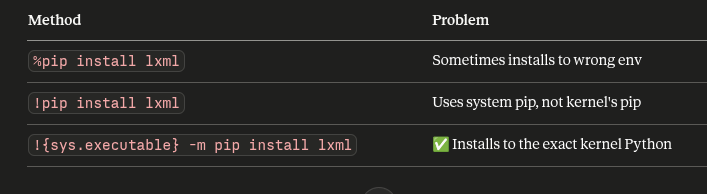

In [5]:
import sys
!{sys.executable} -m pip install lxml


<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<link href="/assets/next/manifest.json" rel="manifest"/>
<style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>
<script defer="" src="/static/js/env-runtime.js"></script>
<script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>
<script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>
<title>AmbitionBox: Discover Best Places To Work - Read Genuine Employee Reviews, Compare Verified Company Salaries, Prepare For Interviews</title><meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/><meta content="
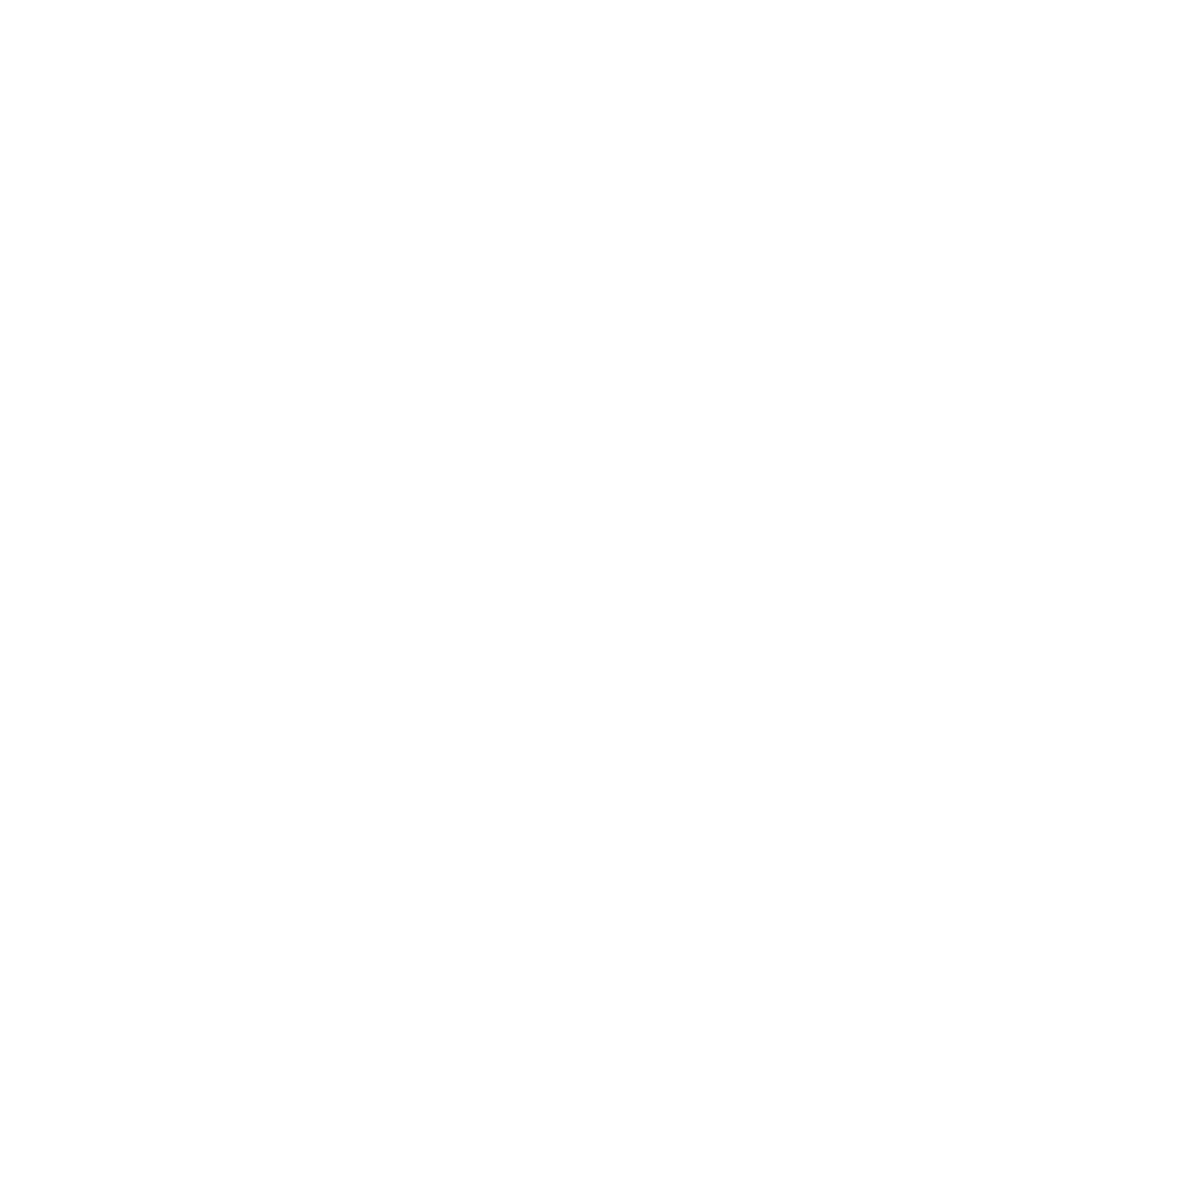

In [6]:
soup = BeautifulSoup(response, "lxml")
soup

# It formate the data nicely

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   AmbitionBox: Discover Best Places To Work - Read Genuine Employee Reviews, Compare Verified Company Salaries, Prepare For Interviews
  </title>
  <meta content="2026 AmbitionBox
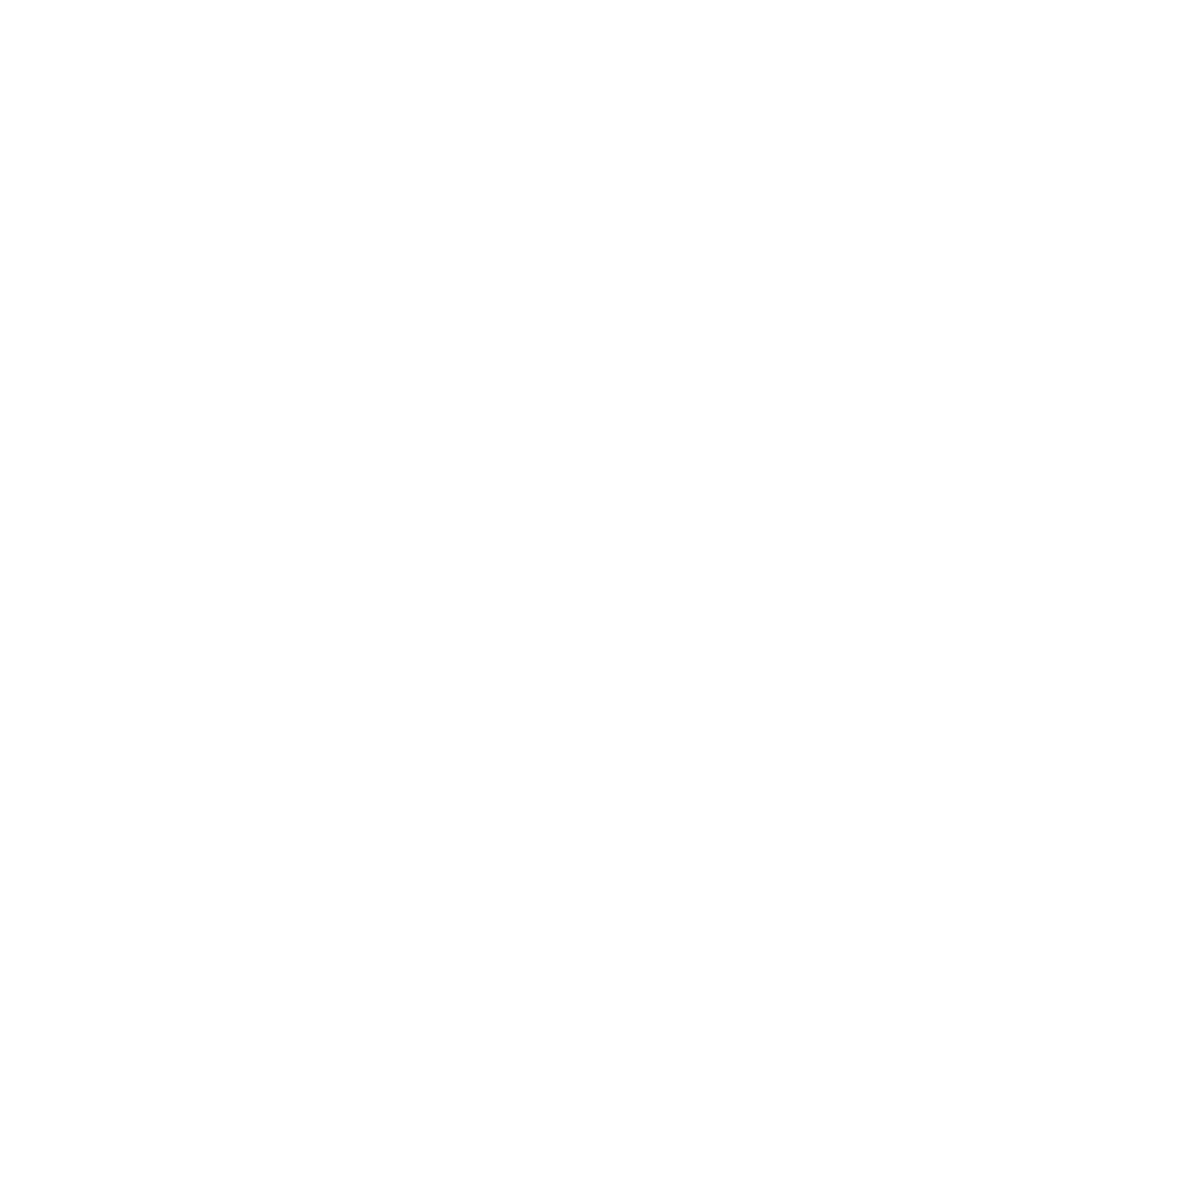

In [7]:
print(soup.prettify())

In [8]:
company = soup.find_all('div', class_='companyCardWrapper')
company

[]

In [9]:

name = []
rating = []
review = []
bad_review = []
domain = []
loc = []

# Salary = []
# Interviews = []
# Jobs = []
# Benefits = []
# Photos = []
tertiaryInformations = []


for i in company:
    name.append(i.find('h2', class_ = 'companyCardWrapper__companyName').text.strip())
    rating.append(i.find('div', class_ = 'rating_star_container').text.strip())
    review.append(i.find('span', class_ = 'companyCardWrapper__companyRatingCount').text.strip()[1:-1])
    TL = i.find('span', class_ = 'companyCardWrapper__interLinking').text.strip().split('|')
    domain.append(TL[0].strip())
    loc.append(TL[1].strip())
    bad_review.append(i.find('span', class_ = 'companyCardWrapper__ratingValues').text.strip())
    
    for j in i.find_all('div', class_ = 'companyCardWrapper__tertiaryInformation'):
        tertiaryInformation = {}
        for k in j.find_all('span', class_ = 'companyCardWrapper__ActionTitle'):
            if k.text.strip() == 'Salary':
                tertiaryInformation['Salary'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Interviews':
                tertiaryInformation['Interviews'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Jobs':
                tertiaryInformation['Jobs'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
            elif k.text.strip() == 'Benefits':
                tertiaryInformation['Benefits'] = j.find('span', class_ = 'companyCardWrapper__ActionCount').text.strip()
        tertiaryInformations.append(tertiaryInformation)


In [10]:
tertiaryInformations

[]

In [11]:
import pandas as pd

df = pd.DataFrame({
    'Company Name': name,
    'Rating': rating,
    'Reviews': review,
    'Bad_Review': bad_review,
    'Domain': domain,
    'Location': loc,
    'Tertiary Informations ': tertiaryInformations
})

print(df.head(2))

Empty DataFrame
Columns: [Company Name, Rating, Reviews, Bad_Review, Domain, Location, Tertiary Informations ]
Index: []


In [12]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

BASE_URL = "https://www.ambitionbox.com/list-of-companies?page={}"

companies_data = []

for page in range(1, 501):

    print(f"Scraping page {page}...")

    response = requests.get(
        BASE_URL.format(page),
        headers=Header,
        timeout=10
    )

    soup = BeautifulSoup(response.text, "lxml")

    company_cards = soup.find_all(
        "div",
        class_="companyCardWrapper"
    )

    if not company_cards:
        print("No more companies found.")
        break

    for card in company_cards:

        # Company basic information
        company_name = card.find(
            "h2",
            class_="companyCardWrapper__companyName"
        )

        rating = card.find(
            "div",
            class_="rating_star_container"
        )

        review_count = card.find(
            "span",
            class_="companyCardWrapper__companyRatingCount"
        )

        interlink = card.find(
            "span",
            class_="companyCardWrapper__interLinking"
        )

        bad_review = card.find(
            "span",
            class_="companyCardWrapper__ratingValues"
        )

        domain = None
        location = None

        if interlink:
            parts = interlink.text.strip().split("|")

            if len(parts) >= 2:
                domain = parts[0].strip()
                location = parts[1].strip()

        # Extract Reviews, Salaries, Interviews, Jobs...
        stats = {}

        action_wrappers = card.find_all(
            "a",
            class_="companyCardWrapper__ActionWrapper"
        )

        for action in action_wrappers:

            title = action.find(
                "span",
                class_="companyCardWrapper__ActionTitle"
            )

            count = action.find(
                "span",
                class_="companyCardWrapper__ActionCount"
            )

            if title and count:
                stats[title.text.strip()] = count.text.strip()

        companies_data.append({
            "Company Name": company_name.text.strip() if company_name else None,
            "Rating": rating.text.strip() if rating else None,
            "Reviews": review_count.text.strip()[1:-1] if review_count else None,
            "Domain": domain,
            "Location": location,
            "Bad Review": bad_review.text.strip() if bad_review else None,
            "Review Count": stats.get("Reviews"),
            "Salary Count": stats.get("Salaries"),
            "Interview Count": stats.get("Interviews"),
            "Job Count": stats.get("Jobs"),
            "Benefit Count": stats.get("Benefits"),
            "Photo Count": stats.get("Photos")
        })

df = pd.DataFrame(companies_data)

print(df.head())
print(df.shape)

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...
Scraping 

In [13]:
df.head(10)

,Company Name,Rating,Reviews,Domain,Location,Bad Review,Review Count,Salary Count,Interview Count,Job Count,Benefit Count,Photo Count
0,TCS,3.3,1.2L,IT Services & Consulting,Bengaluru +445 other locations,Job Security,1.2L,10.2L,11.4k,4.7k,10.8k,93
1,Accenture,3.7,74.2k,IT Services & Consulting,Bengaluru +259 other locations,"Promotions, Salary, Work Satisfaction",74.2k,7.1L,9.4k,36.9k,6.8k,49
2,Wipro,3.6,65.6k,IT Services & Consulting,Hyderabad +374 other locations,"Promotions, Salary, Work Satisfaction",65.6k,4.9L,6.9k,326,4.8k,114
3,Cognizant,3.7,62k,IT Services & Consulting,Hyderabad +233 other locations,"Promotions, Salary, Work Satisfaction",62k,6.1L,6.5k,702,5.6k,102
4,Capgemini,3.6,54k,IT Services & Consulting,Bengaluru +183 other locations,"Work Life Balance, Job Security",54k,4.9L,5.6k,2.3k,3.8k,42
5,HDFC Bank,3.8,53k,Banking,Mumbai +1856 other locations,"Job Security, Skill Development",53k,1.5L,3.1k,327,3.4k,92
6,Infosys,3.5,49.3k,IT Services & Consulting,Bengaluru +246 other locations,Job Security,49.3k,5.3L,8.5k,2.6k,4.9k,120
7,HCLTech,3.4,46.4k,IT Services & Consulting,Chennai +231 other locations,"Promotions, Salary, Work Satisfaction",46.4k,3.9L,4.6k,315,3.9k,71
8,ICICI Bank,3.9,46.3k,Banking,Mumbai +1446 other locations,"Job Security, Promotions, Skill Development",46.3k,1.5L,3k,10,3.8k,73
9,Tech Mahindra,3.4,43.7k,IT Services & Consulting,Hyderabad +323 other locations,"Promotions, Salary, Work Satisfaction",43.7k,2.9L,4.6k,633,3.4k,79


In [14]:
print(df.shape)
print(df.head())
print(df.info())

(10000, 12)
  Company Name Rating Reviews                    Domain  \
0          TCS    3.3    1.2L  IT Services & Consulting   
1    Accenture    3.7   74.2k  IT Services & Consulting   
2        Wipro    3.6   65.6k  IT Services & Consulting   
3    Cognizant    3.7     62k  IT Services & Consulting   
4    Capgemini    3.6     54k  IT Services & Consulting   

                         Location                             Bad Review  \
0  Bengaluru +445 other locations                           Job Security   
1  Bengaluru +259 other locations  Promotions, Salary, Work Satisfaction   
2  Hyderabad +374 other locations  Promotions, Salary, Work Satisfaction   
3  Hyderabad +233 other locations  Promotions, Salary, Work Satisfaction   
4  Bengaluru +183 other locations        Work Life Balance, Job Security   

  Review Count Salary Count Interview Count Job Count Benefit Count  \
0         1.2L        10.2L           11.4k      4.7k         10.8k   
1        74.2k         7.1L       

In [15]:
df.to_csv(
    'company.csv',
    index=False,
    encoding='utf-8'
)